In [1]:
import numpy as np

In [10]:
def is_pos_def(A):
    if np.array_equal(A,A.T): #判断对称矩阵
        try:
            np.linalg.cholesky(A)
            return T
        #报错提示信息可以是LinAlgError
        #代码捕获报错需要是完整路径:np.linalg.LinAlgError
        except np.linalg.LinAlgError:
            return False
    else:
        return False #如果不是对称矩阵,直接返回False

In [7]:
A = np.array([[1,0],
              [0,0]])

In [8]:
print(is_pos_def(A))

False


In [9]:
 np.linalg.cholesky(A)

LinAlgError: Matrix is not positive definite

In [11]:
import sympy
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def mesh_circ(c1,c2,r,num):
    theta = np.arange(0,2*np.pi + np.pi,np.pi/num)
    r = np.arange(0,r,r/num)
    theta,r = np.meshgrid(theta,r)
    xx1 = np.cos(theta)*r + c1
    xx2 = np.sin(theta)*r + c2
    return xx1,xx2

In [23]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[1.5,0.5],
              [0.5,1.5]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
f_x

x1*(1.5*x1 + 0.5*x2) + x2*(0.5*x1 + 1.5*x2)

In [24]:
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
grad_f

[3.0*x1 + 1.0*x2, 1.0*x1 + 3.0*x2]

In [25]:
f_x_fcn = sympy.lambdify([x1,x2],f_x)

In [26]:
grad_fcn = sympy.lambdify([x1,x2],grad_f)

In [27]:
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)

In [28]:
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量

In [29]:
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

In [30]:
color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

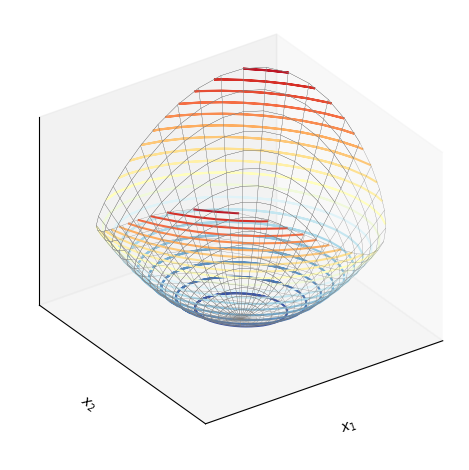

In [33]:
ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局

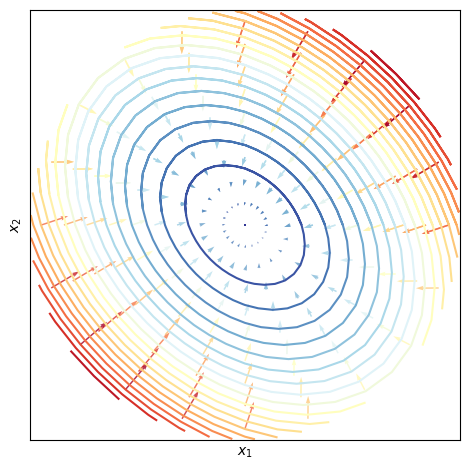

In [35]:
fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

In [41]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[1,0],
              [0,0]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

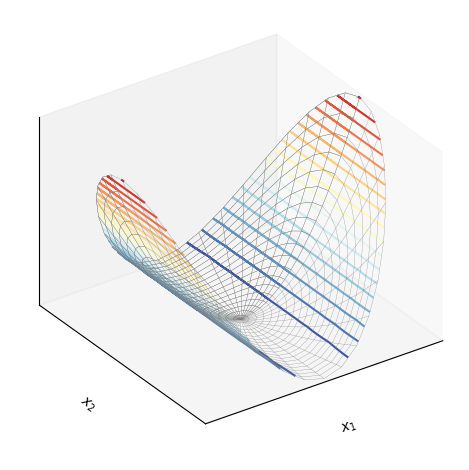

In [42]:
ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局

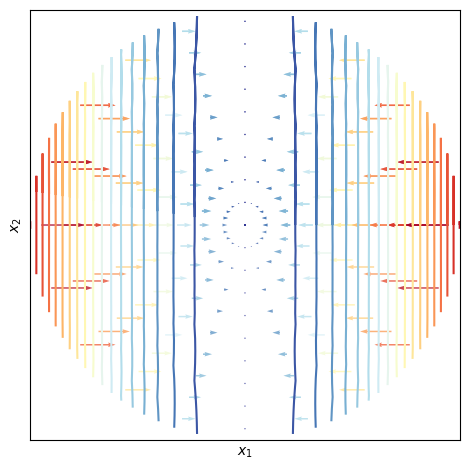

In [43]:
fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

In [44]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[0.5,-0.5],
              [-0.5,0.5]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

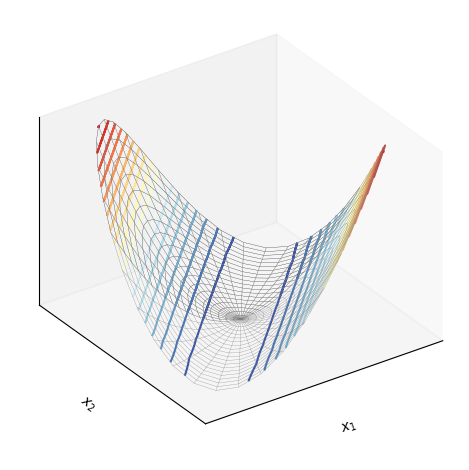

In [45]:
ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局

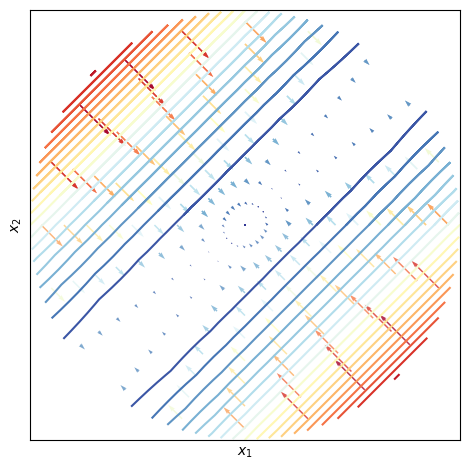

In [46]:
fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

In [47]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[-1,0],
              [0,-2]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

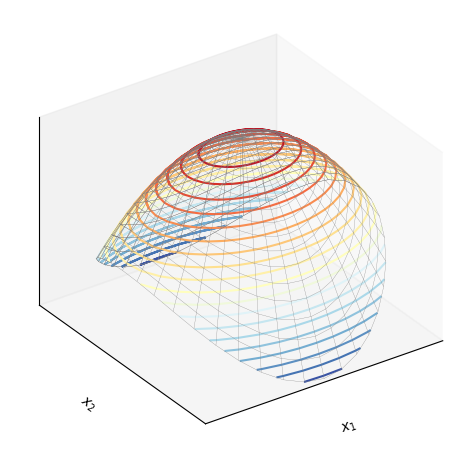

In [48]:
ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局

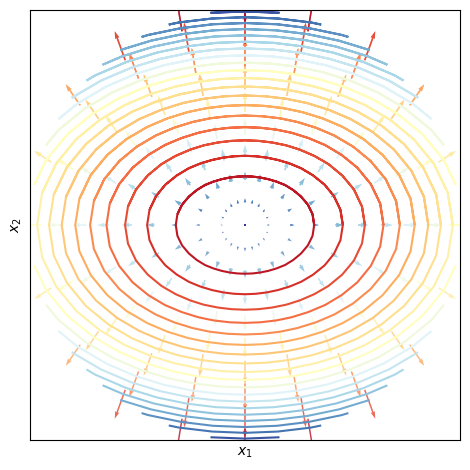

In [49]:
fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

In [50]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[1,0],
              [0,-1]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

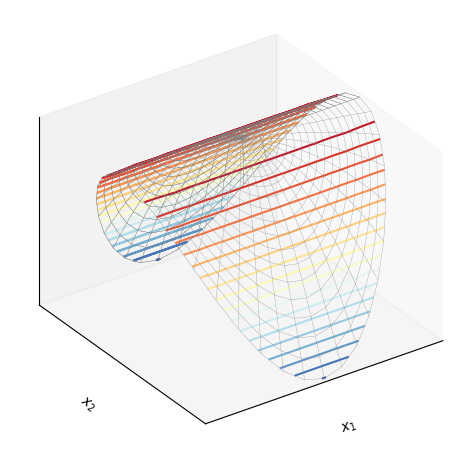

In [51]:
ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局

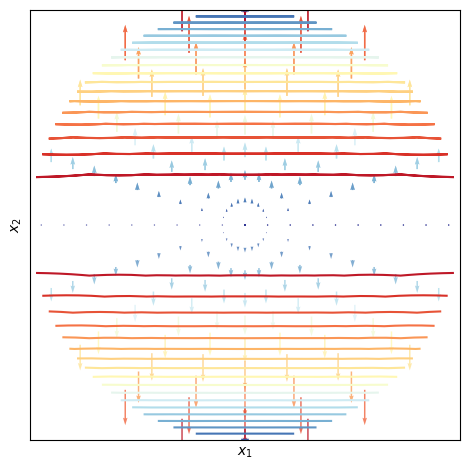

In [52]:
fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

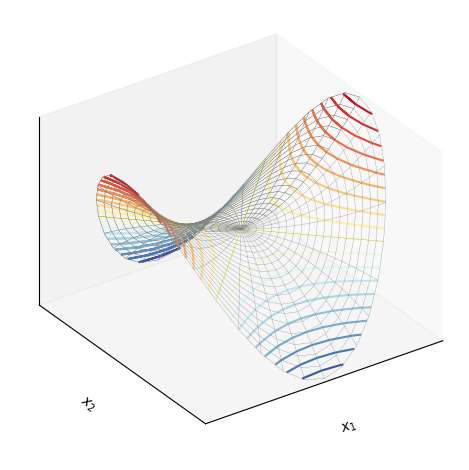

In [54]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[1,0],
              [0,-1]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局


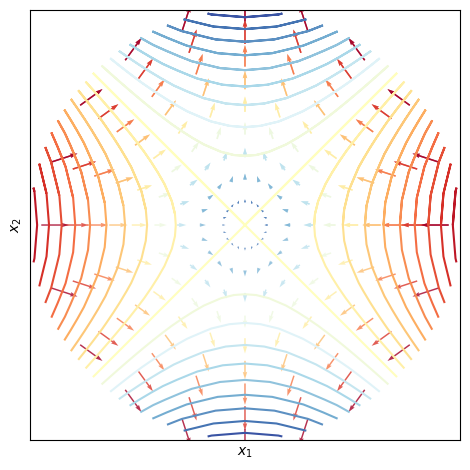

In [55]:

fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

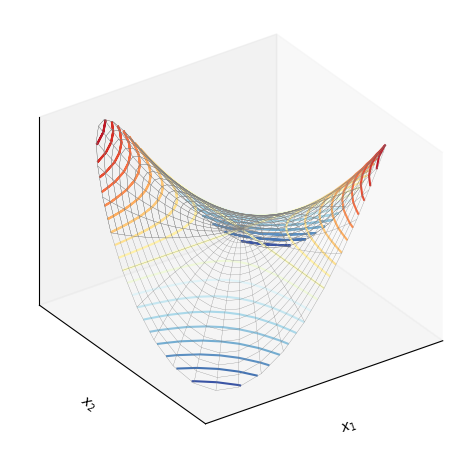

In [56]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[0,-1],
              [-1,0]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局


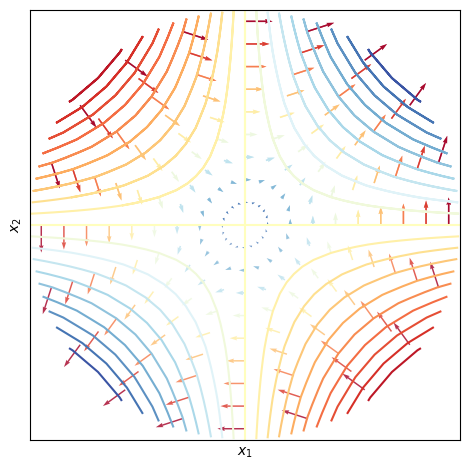

In [57]:

fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

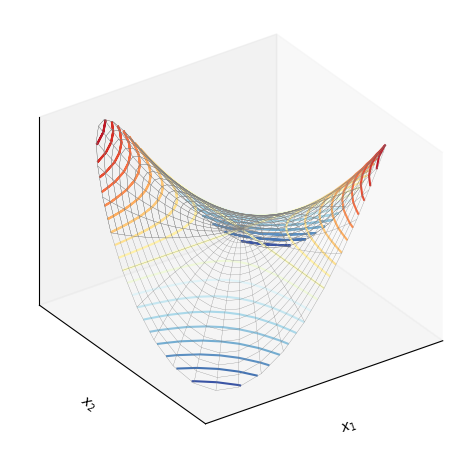

In [59]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[0,-1],
              [-1,0]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局


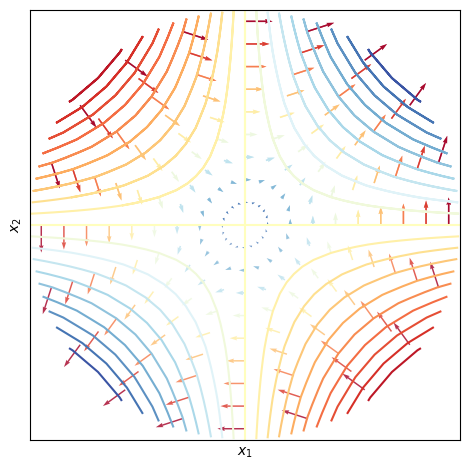

In [60]:

fig,ax = plt.subplots()
plt.quiver(xx1_,xx2_,-V[0],-V[1],color_array,angles = 'xy',scale_units = 'xy',
           edgecolor= 'none',alpha = 0.8,cmap = 'RdYlBu_r')
plt.contour(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.set_aspect('equal')  # 设置图形纵横比
ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
plt.tight_layout()  # 调整布局

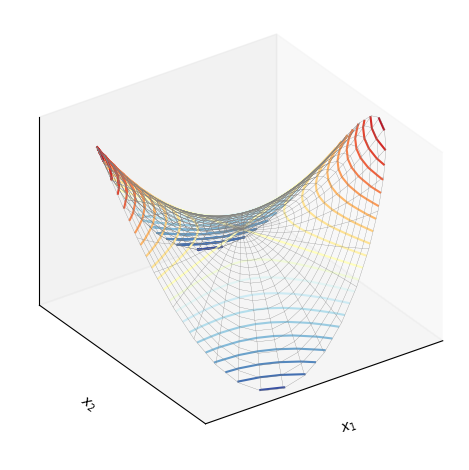

In [61]:
x1,x2 = sympy.symbols('x1 x2')
A = np.array([[1,-1],
              [-1,-1]])
x = np.array([[x1,x2]]).T
f_x = x.T @ A @x
f_x = f_x[0][0] #提取出标量的函数表达式
grad_f = [sympy.diff(f_x,var) for var in (x1,x2)]
f_x_fcn = sympy.lambdify([x1,x2],f_x)
grad_fcn = sympy.lambdify([x1,x2],grad_f)
xx1,xx2 = mesh_circ(0,0,4,20)
xx1_,xx2_ = mesh_circ(0,0,4,10)
#同一位置组成一个点作为输入,去广播
V = grad_fcn(xx1_,xx2_)
V_z = np.ones_like(V[1]) #单位z分量
if isinstance(V[1],int): #判断是不是某种类型,只判断这一个对象是不是这个类型
    #一般情况下为整数,是为0的情况,变为全零数组
    V[1] = np.zeros_like(V[0])
elif isinstance(V[0],int):
    V[0] = np.zeros_like(V[1])

ff_x = f_x_fcn(xx1,xx2)

color_array = np.sqrt(V[0] ** 2 + V[1]**2)
l_3D_vectors = np.sqrt(V[0] ** 2 + V[1] ** 2 + V_z**2)

ax = plt.figure().add_subplot(projection = '3d')
ax.plot_wireframe(xx1,xx2,ff_x,rstride = 1,cstride = 1,color = '0.5',
                  linewidth = 0.2)
ax.contour3D(xx1,xx2,ff_x,20,cmap = 'RdYlBu_r')

ax.xaxis.set_ticks([])  # 隐藏 x 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 z 轴刻度
plt.xlim(xx1.min(), xx1.max())  # 设置 x 轴范围
plt.ylim(xx2.min(), xx2.max())  # 设置 y 轴范围
ax.set_proj_type('ortho')  # 设置投影类型为正交
ax.view_init(30, -125)  # 设置视角角度
ax.set_xlabel('$x_1$')  # 设置 x 轴标签
ax.set_ylabel('$x_2$')  # 设置 y 轴标签
ax.set_zlabel('$f(x_1,x_2)$')  # 设置 z 轴标签
plt.tight_layout()  # 调整布局
